<a href="https://colab.research.google.com/github/nageshgnn/E_commerce_Marketing_and_sales_Business_CaseStudy/blob/main/e-commerce_marketing_and_sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Problem Statement
2. Understanding the data
3. Data Handling / Data Processing
4. Analyis (EDA) / Business questions
5. Insights and Recommendation

 ## 1. Problem Statement

 The e-commerce company aims to leverage data-driven insights to enhance customer acquisition, retention, and revenue optimization. The following analysis will be conducted to understand key business trends and improve decision-making.

## 2. Understanding the Data

Let's load all the datasets and inspect its initial structure. This will help us get a first look at the columns, data types, and overall content.

Following are the datasets:
1. Customers.csv
2. Discount_Coupon.csv
3. Marketing_Spend.csv
4. Online_Sales.csv
5. Tax_amount.csv

In [5]:
import pandas as pd

# Load CustomersData.xlsx
file_path = '/content/CustomersData.xlsx'
customer_df = pd.read_excel(file_path)
print(f"Successfully loaded data from: {file_path}")
display(customer_df.head())

# Load Discount_Coupon.csv
file_path = '/content/Discount_Coupon.csv'
discount_df = pd.read_csv(file_path)
print(f"Successfully loaded data from: {file_path}")
display(discount_df.head())

# Load Marketing_Spend.csv
file_path = '/content/Marketing_Spend.csv'
marketing_spend_df = pd.read_csv(file_path)
print(f"Successfully loaded data from: {file_path}")
display(marketing_spend_df.head())

# Load Online_Sales.csv
file_path = '/content/Online_Sales.csv'
online_sales_df = pd.read_csv(file_path)
print(f"Successfully loaded data from: {file_path}")
display(online_sales_df.head())

# Load Tax_amount.xlsx
file_path = '/content/Tax_amount.xlsx'
tax_amount_df = pd.read_excel(file_path)
print(f"Successfully loaded data from: {file_path}")
display(tax_amount_df.head())

Successfully loaded data from: /content/CustomersData.xlsx


,CustomerID,Gender,Location,Tenure_Months
0,17850,M,Chicago,12
1,13047,M,California,43
2,12583,M,Chicago,33
3,13748,F,California,30
4,15100,M,California,49


Successfully loaded data from: /content/Discount_Coupon.csv


,Month,Product_Category,Coupon_Code,Discount_pct
0,Jan,Apparel,SALE10,10
1,Feb,Apparel,SALE20,20
2,Mar,Apparel,SALE30,30
3,Jan,Nest-USA,ELEC10,10
4,Feb,Nest-USA,ELEC20,20


Successfully loaded data from: /content/Marketing_Spend.csv


,Date,Offline_Spend,Online_Spend
0,1/1/2019,4500,2424.50
1,1/2/2019,4500,3480.36
2,1/3/2019,4500,1576.38
3,1/4/2019,4500,2928.55
4,1/5/2019,4500,4055.30


Successfully loaded data from: /content/Online_Sales.csv


,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status
0,17850,16679,1/1/2019,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used
1,17850,16680,1/1/2019,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used
2,17850,16681,1/1/2019,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used
3,17850,16682,1/1/2019,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used
4,17850,16682,1/1/2019,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used


Successfully loaded data from: /content/Tax_amount.xlsx


,Product_Category,GST
0,Nest-USA,0.10
1,Office,0.10
2,Apparel,0.18
3,Bags,0.18
4,Drinkware,0.18


In [6]:
customer_df['CustomerID'] = customer_df['CustomerID'].astype(str)
print("CustomerID column in customer_df converted to string type.")

CustomerID column in customer_df converted to string type.


In [7]:
print("Info for customer_df after converting CustomerID to string:")
customer_df.info()

Info for customer_df after converting CustomerID to string:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1468 entries, 0 to 1467
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1468 non-null   object
 1   Gender         1468 non-null   object
 2   Location       1468 non-null   object
 3   Tenure_Months  1468 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 46.0+ KB


### Checking for Missing Values in `customer_df`

In [8]:
print("Missing values in customer_df:")
display(customer_df.isnull().sum())

Missing values in customer_df:


,0
CustomerID,0
Gender,0
Location,0
Tenure_Months,0


### Checking for Missing Values in `discount_df`

In [9]:
print("Missing values in discount_df:")
display(discount_df.isnull().sum())

Missing values in discount_df:


,0
Month,0
Product_Category,0
Coupon_Code,0
Discount_pct,0


### Checking for Missing Values in `marketing_spend_df`

In [10]:
print("Missing values in marketing_spend_df:")
display(marketing_spend_df.isnull().sum())

Missing values in marketing_spend_df:


,0
Date,0
Offline_Spend,0
Online_Spend,0


### Checking for Missing Values in `online_sales_df`

In [11]:
print("Missing values in online_sales_df:")
display(online_sales_df.isnull().sum())

Missing values in online_sales_df:


,0
CustomerID,0
Transaction_ID,0
Transaction_Date,0
Product_SKU,0
Product_Description,0
Product_Category,0
Quantity,0
Avg_Price,0
Delivery_Charges,0
Coupon_Status,0


### Checking for Missing Values in `tax_amount_df`

In [12]:
print("Missing values in tax_amount_df:")
display(tax_amount_df.isnull().sum())

Missing values in tax_amount_df:


,0
Product_Category,0
GST,0


### Data Types and Info for `customer_df`

In [13]:
print("Info for customer_df:")
customer_df.info()

Info for customer_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1468 entries, 0 to 1467
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1468 non-null   object
 1   Gender         1468 non-null   object
 2   Location       1468 non-null   object
 3   Tenure_Months  1468 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 46.0+ KB


### Data Types and Info for `discount_df`

In [14]:
print("Info for discount_df:")
discount_df.info()

Info for discount_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Month             204 non-null    object
 1   Product_Category  204 non-null    object
 2   Coupon_Code       204 non-null    object
 3   Discount_pct      204 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 6.5+ KB


### Data Types and Info for `marketing_spend_df`

In [15]:
print("Info for marketing_spend_df:")
marketing_spend_df.info()

Info for marketing_spend_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           365 non-null    object 
 1   Offline_Spend  365 non-null    int64  
 2   Online_Spend   365 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 8.7+ KB


### Data Types and Info for `online_sales_df`

In [16]:
print("Info for online_sales_df:")
online_sales_df.info()

Info for online_sales_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           52924 non-null  int64  
 1   Transaction_ID       52924 non-null  int64  
 2   Transaction_Date     52924 non-null  object 
 3   Product_SKU          52924 non-null  object 
 4   Product_Description  52924 non-null  object 
 5   Product_Category     52924 non-null  object 
 6   Quantity             52924 non-null  int64  
 7   Avg_Price            52924 non-null  float64
 8   Delivery_Charges     52924 non-null  float64
 9   Coupon_Status        52924 non-null  object 
dtypes: float64(2), int64(3), object(5)
memory usage: 4.0+ MB


### Data Types and Info for `tax_amount_df`

In [17]:
print("Info for tax_amount_df:")
tax_amount_df.info()

Info for tax_amount_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product_Category  20 non-null     object 
 1   GST               20 non-null     float64
dtypes: float64(1), object(1)
memory usage: 452.0+ bytes


In [18]:
online_sales_df['CustomerID'] = online_sales_df['CustomerID'].astype(str)
print("CustomerID column in online_sales_df converted to string type.")

CustomerID column in online_sales_df converted to string type.


In [24]:
print("Info for online_sales_df after converting CustomerID to string:")
online_sales_df.info()

Info for online_sales_df after converting CustomerID to string:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           52924 non-null  object 
 1   Transaction_ID       52924 non-null  int64  
 2   Transaction_Date     52924 non-null  object 
 3   Product_SKU          52924 non-null  object 
 4   Product_Description  52924 non-null  object 
 5   Product_Category     52924 non-null  object 
 6   Quantity             52924 non-null  int64  
 7   Avg_Price            52924 non-null  float64
 8   Delivery_Charges     52924 non-null  float64
 9   Coupon_Status        52924 non-null  object 
dtypes: float64(2), int64(2), object(6)
memory usage: 4.0+ MB


In [19]:
print(f"Total number of unique customers: {customer_df['CustomerID'].nunique()}")
print(f"Total number of unique locations: {customer_df['Location'].nunique()}")
print(f"Total number of unique Tenure months: {customer_df['Tenure_Months'].nunique()}")

Total number of unique customers: 1468
Total number of unique locations: 5
Total number of unique Tenure months: 49


In [20]:
print(f"Total number of unique product categories (from discount_df): {discount_df['Product_Category'].nunique()}")
print(f"Total number of unique coupon codes (from discount_df): {discount_df['Coupon_Code'].nunique()}")

Total number of unique product categories (from discount_df): 17
Total number of unique coupon codes (from discount_df): 48


In [21]:
# Convert 'Date' column in marketing_spend_df to datetime
marketing_spend_df['Date'] = pd.to_datetime(marketing_spend_df['Date'])
print("Converted 'Date' column in marketing_spend_df to datetime.")

Converted 'Date' column in marketing_spend_df to datetime.


In [22]:
# Extract 'Month' from 'Date' in marketing_spend_df
marketing_spend_df['Month'] = marketing_spend_df['Date'].dt.month
print("Extracted 'Month' column from 'Date' in marketing_spend_df.")

Extracted 'Month' column from 'Date' in marketing_spend_df.


In [23]:
print("Info for marketing_spend_df after date processing:")
marketing_spend_df.info()

Info for marketing_spend_df after date processing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           365 non-null    datetime64[ns]
 1   Offline_Spend  365 non-null    int64         
 2   Online_Spend   365 non-null    float64       
 3   Month          365 non-null    int32         
dtypes: datetime64[ns](1), float64(1), int32(1), int64(1)
memory usage: 10.1 KB


In [24]:
# Convert 'Transaction_Date' column in online_sales_df to datetime
online_sales_df['Transaction_Date'] = pd.to_datetime(online_sales_df['Transaction_Date'])
print("Converted 'Transaction_Date' column in online_sales_df to datetime.")

Converted 'Transaction_Date' column in online_sales_df to datetime.


In [25]:
# Extract 'Month' from 'Transaction_Date' in online_sales_df
online_sales_df['Month'] = online_sales_df['Transaction_Date'].dt.month
print("Extracted 'Month' column from 'Transaction_Date' in online_sales_df.")

Extracted 'Month' column from 'Transaction_Date' in online_sales_df.


In [26]:
print("Info for online_sales_df after date processing:")
online_sales_df.info()

Info for online_sales_df after date processing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CustomerID           52924 non-null  object        
 1   Transaction_ID       52924 non-null  int64         
 2   Transaction_Date     52924 non-null  datetime64[ns]
 3   Product_SKU          52924 non-null  object        
 4   Product_Description  52924 non-null  object        
 5   Product_Category     52924 non-null  object        
 6   Quantity             52924 non-null  int64         
 7   Avg_Price            52924 non-null  float64       
 8   Delivery_Charges     52924 non-null  float64       
 9   Coupon_Status        52924 non-null  object        
 10  Month                52924 non-null  int32         
dtypes: datetime64[ns](1), float64(2), int32(1), int64(2), object(5)
memory usage: 4.2+ MB


### Data Handling/ Data Processing Further Data Exploration: Unique Counts

In [27]:
print(f"Total number of unique Product SKUs (from online_sales_df): {online_sales_df['Product_SKU'].nunique()}")
print(f"Total number of unique Product Categories (from online_sales_df): {online_sales_df['Product_Category'].nunique()}")
print(f"Total number of unique Coupon Statuses (from online_sales_df): {online_sales_df['Coupon_Status'].nunique()}")
print(f"Total number of unique Product Categories (from tax_amount_df): {tax_amount_df['Product_Category'].nunique()}")

Total number of unique Product SKUs (from online_sales_df): 1145
Total number of unique Product Categories (from online_sales_df): 20
Total number of unique Coupon Statuses (from online_sales_df): 3
Total number of unique Product Categories (from tax_amount_df): 20


### Detailed Exploration of Categorical Variables: Value Counts

In [28]:
print("Value counts for 'Product_Category' in online_sales_df:")
display(online_sales_df['Product_Category'].value_counts())

print("\nValue counts for 'Coupon_Status' in online_sales_df:")
display(online_sales_df['Coupon_Status'].value_counts())

print("\nValue counts for 'Product_Category' in tax_amount_df:")
display(tax_amount_df['Product_Category'].value_counts())

Value counts for 'Product_Category' in online_sales_df:


,count
Product_Category,
Apparel,18126
Nest-USA,14013
Office,6513
Drinkware,3483
Lifestyle,3092
Nest,2198
Bags,1882
Headgear,771
Notebooks & Journals,749



Value counts for 'Coupon_Status' in online_sales_df:


,count
Coupon_Status,
Clicked,26926
Used,17904
Not Used,8094



Value counts for 'Product_Category' in tax_amount_df:


,count
Product_Category,
Nest-USA,1
Office,1
Apparel,1
Bags,1
Drinkware,1
Lifestyle,1
Notebooks & Journals,1
Headgear,1
Waze,1


## Calculating Invoice Value

To calculate the `Invoice Value`, we need to combine information from `online_sales_df`, `discount_df`, and `tax_amount_df`. This involves several steps:

1.  **Prepare `online_sales_df`:** Convert the numeric `Month` column to month names (e.g., 1 to 'Jan') to match `discount_df`.
2.  **Merge with `discount_df`:** Join `online_sales_df` with `discount_df` on `Month` and `Product_Category`.
3.  **Merge with `tax_amount_df`:** Join the combined dataframe with `tax_amount_df` on `Product_Category`.
4.  **Handle Missing Values:** Fill any missing `Discount_pct` or `GST` values that arise from the merges.
5.  **Calculate `Invoice Value`:** Apply the formula, ensuring `Discount_pct` is only applied when `Coupon_Status` is 'Used'.

In [29]:
import calendar

# Convert numeric month to month name in online_sales_df
online_sales_df['Month_Name'] = online_sales_df['Month'].apply(lambda x: calendar.month_abbr[x] if pd.notnull(x) else x)

# Display the first few rows with the new 'Month_Name' column
print("Online Sales DataFrame with 'Month_Name' column:")
display(online_sales_df[['Transaction_Date', 'Month', 'Month_Name', 'Product_Category']].head())

Online Sales DataFrame with 'Month_Name' column:


,Transaction_Date,Month,Month_Name,Product_Category
0,2019-01-01,1,Jan,Nest-USA
1,2019-01-01,1,Jan,Nest-USA
2,2019-01-01,1,Jan,Office
3,2019-01-01,1,Jan,Apparel
4,2019-01-01,1,Jan,Bags


In [30]:
# Merge online_sales_df with discount_df
# Use a left merge to keep all online sales records
merged_df = pd.merge(
    online_sales_df,
    discount_df[['Month', 'Product_Category', 'Discount_pct']],
    left_on=['Month_Name', 'Product_Category'],
    right_on=['Month', 'Product_Category'],
    how='left',
    suffixes=('_sales', '_discount')
)

# Drop the redundant 'Month_discount' column
merged_df.drop(columns=['Month_discount'], inplace=True)

# Merge with tax_amount_df
merged_df = pd.merge(
    merged_df,
    tax_amount_df[['Product_Category', 'GST']],
    on='Product_Category',
    how='left'
)

# Fill NaN for Discount_pct and GST: Assume no discount (0%) if not matched, and 0 GST if not matched
merged_df['Discount_pct'] = merged_df['Discount_pct'].fillna(0)
merged_df['GST'] = merged_df['GST'].fillna(0)

# Display info and head of the merged dataframe to check columns and types
print("Info of the merged DataFrame:")
merged_df.info()
print("\nHead of the merged DataFrame:")
display(merged_df.head())

Info of the merged DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CustomerID           52924 non-null  object        
 1   Transaction_ID       52924 non-null  int64         
 2   Transaction_Date     52924 non-null  datetime64[ns]
 3   Product_SKU          52924 non-null  object        
 4   Product_Description  52924 non-null  object        
 5   Product_Category     52924 non-null  object        
 6   Quantity             52924 non-null  int64         
 7   Avg_Price            52924 non-null  float64       
 8   Delivery_Charges     52924 non-null  float64       
 9   Coupon_Status        52924 non-null  object        
 10  Month_sales          52924 non-null  int32         
 11  Month_Name           52924 non-null  object        
 12  Discount_pct         52924 non-null  float64       
 13  G

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Month_sales,Month_Name,Discount_pct,GST
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,1,Jan,10.0,0.10
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,1,Jan,10.0,0.10
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,1,Jan,10.0,0.10
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,1,Jan,10.0,0.18
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,1,Jan,10.0,0.18


In [31]:
# Calculate the effective discount percentage
# Discount is applied only if 'Coupon_Status' is 'Used'
merged_df['Effective_Discount_Factor'] = merged_df.apply(
    lambda row: (1 - (row['Discount_pct'] / 100)) if row['Coupon_Status'] == 'Used' else 1,
    axis=1
)

# Calculate Invoice Value
# Formula: ((Quantity * Avg_price) * (1 - Discount_pct) * (1 + GST)) + Delivery_Charges
merged_df['Invoice_Value'] = (
    (merged_df['Quantity'] * merged_df['Avg_Price']) * merged_df['Effective_Discount_Factor'] * (1 + merged_df['GST'])
    + merged_df['Delivery_Charges']
)

# Display the first few rows with the new 'Invoice_Value' column
print("Merged DataFrame with calculated 'Invoice_Value' and 'Effective_Discount_Factor':")
display(merged_df[['Transaction_ID', 'Quantity', 'Avg_Price', 'Coupon_Status', 'Discount_pct', 'Effective_Discount_Factor', 'GST', 'Delivery_Charges', 'Invoice_Value']].head())

Merged DataFrame with calculated 'Invoice_Value' and 'Effective_Discount_Factor':


,Transaction_ID,Quantity,Avg_Price,Coupon_Status,Discount_pct,Effective_Discount_Factor,GST,Delivery_Charges,Invoice_Value
0,16679,1,153.71,Used,10.0,0.9,0.10,6.5,158.6729
1,16680,1,153.71,Used,10.0,0.9,0.10,6.5,158.6729
2,16681,1,2.05,Used,10.0,0.9,0.10,6.5,8.5295
3,16682,5,17.53,Not Used,10.0,1.0,0.18,6.5,109.9270
4,16682,1,16.50,Used,10.0,0.9,0.18,6.5,24.0230


In [32]:
merged_df["Invoice_Value"].describe()

,Invoice_Value
count,52924.000000
mean,101.983198
std,172.365729
min,4.603500
25%,20.160000
50%,45.636200
75%,137.400000
max,8979.275000


## Identifying the months with the highest and lowest acquisition count. Strategies could be implemented to address the fluctuations and ensure consistent growth throughout the year

In [33]:
# Find the first transaction date for each customer (acquisition date)
first_transaction_date = online_sales_df.groupby('CustomerID')['Transaction_Date'].min().reset_index()
first_transaction_date.rename(columns={'Transaction_Date': 'Acquisition_Date'}, inplace=True)

# Extract the month from the acquisition date
first_transaction_date['Acquisition_Month'] = first_transaction_date['Acquisition_Date'].dt.month_name()

# Calculate the number of acquisitions per month
monthly_acquisitions = first_transaction_date.groupby('Acquisition_Month').size().reset_index(name='Acquisition_Count')

# Sort by month to ensure correct order for display (optional, but good practice)
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_acquisitions['Acquisition_Month'] = pd.Categorical(monthly_acquisitions['Acquisition_Month'], categories=month_order, ordered=True)
monthly_acquisitions = monthly_acquisitions.sort_values('Acquisition_Month')

print("Monthly Customer Acquisition Counts:")
display(monthly_acquisitions)

# Identify months with highest and lowest acquisition count
highest_acquisition_month = monthly_acquisitions.loc[monthly_acquisitions['Acquisition_Count'].idxmax()]
lowest_acquisition_month = monthly_acquisitions.loc[monthly_acquisitions['Acquisition_Count'].idxmin()]

print(f"\nMonth with highest acquisition count: {highest_acquisition_month['Acquisition_Month']} (Count: {highest_acquisition_month['Acquisition_Count']})")
print(f"Month with lowest acquisition count: {lowest_acquisition_month['Acquisition_Month']} (Count: {lowest_acquisition_month['Acquisition_Count']})")

Monthly Customer Acquisition Counts:


,Acquisition_Month,Acquisition_Count
4,January,215
3,February,96
7,March,177
0,April,163
8,May,112
6,June,137
5,July,94
1,August,135
11,September,78
10,October,87



Month with highest acquisition count: January (Count: 215)
Month with lowest acquisition count: November (Count: 68)


### Strategies to address fluctuations and ensure consistent growth:

Based on the identified months with high and low acquisition counts, here are some general strategies that could be implemented:

1.  **Analyze Causes of Fluctuations:**
    *   **High Months:** Investigate what factors contributed to high acquisitions during these periods (e.g., successful marketing campaigns, seasonal trends, product launches, holiday sales). Replicate these successful strategies in other periods.
    *   **Low Months:** Understand why acquisitions were low. Was there decreased marketing spend, economic downturns, increased competition, or simply a seasonal lull? This diagnostic step is crucial.

2.  **Marketing & Promotional Strategies:**
    *   **Off-Season Promotions:** Introduce targeted promotions, discounts, or bundles during historically low acquisition months to stimulate demand.
    *   **Always-On Campaigns:** Maintain a baseline level of marketing activity throughout the year, rather than solely focusing on peak seasons.
    *   **Diversify Channels:** If certain channels perform well during specific months, explore diversifying marketing channels to reach new audiences or maintain engagement when primary channels are less effective.

3.  **Product & Service Enhancements:**
    *   **Seasonal Offerings:** Introduce new products or services that align with specific times of the year, potentially filling gaps during low periods.
    *   **Loyalty Programs:** Implement or enhance loyalty programs to encourage repeat purchases and word-of-mouth referrals, which can provide a more consistent acquisition stream.

4.  **Customer Engagement:**
    *   **Content Marketing:** Develop evergreen content that attracts customers year-round, regardless of seasonal trends.
    *   **Community Building:** Foster a strong customer community to drive organic growth and reduce reliance on seasonal pushes.

5.  **Budget Allocation:**
    *   **Strategic Spending:** Reallocate marketing budget to support initiatives during low acquisition periods, balancing spend between peak and off-peak seasons to flatten the acquisition curve.

By understanding the underlying reasons for monthly variations and implementing targeted strategies, the company can work towards more consistent growth and reduce significant acquisition fluctuations throughout the year.

## Analyzing customer behavior during high-retention months and suggestion to replicate this success throughout the year.

### Identifying High-Retention Months by Total Invoice Value

In [34]:
# Calculate total Invoice_Value per month
monthly_invoice_value = merged_df.groupby('Month_Name')['Invoice_Value'].sum().reset_index()

# Sort months for better visualization and understanding
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_invoice_value['Month_Name'] = pd.Categorical(monthly_invoice_value['Month_Name'], categories=month_order, ordered=True)
monthly_invoice_value = monthly_invoice_value.sort_values('Month_Name')

print("Total Invoice Value per Month:")
display(monthly_invoice_value)

highest_retention_month = monthly_invoice_value.loc[monthly_invoice_value['Invoice_Value'].idxmax()]
lowest_retention_month = monthly_invoice_value.loc[monthly_invoice_value['Invoice_Value'].idxmin()]

print(f"\nMonth with highest total Invoice Value (high retention): {highest_retention_month['Month_Name']} (Total Value: {highest_retention_month['Invoice_Value']:.2f})")
print(f"Month with lowest total Invoice Value (low retention): {lowest_retention_month['Month_Name']} (Total Value: {lowest_retention_month['Invoice_Value']:.2f})")

Total Invoice Value per Month:


,Month_Name,Invoice_Value
4,Jan,494090.54875
3,Feb,375162.04730
7,Mar,415157.79044
0,Apr,477498.59102
8,May,365596.02956
6,Jun,361000.17429
5,Jul,451878.40904
1,Aug,475796.87554
11,Sep,396510.49254
10,Oct,480767.36981



Month with highest total Invoice Value (high retention): Dec (Total Value: 556112.29)
Month with lowest total Invoice Value (low retention): Jun (Total Value: 361000.17)


### Analyzing Customer Behavior in High-Retention Months

In [35]:
# For this example, let's analyze the behavior in the month identified as 'highest_retention_month'
high_retention_month_name = highest_retention_month['Month_Name']
filtered_df_high_retention = merged_df[merged_df['Month_Name'] == high_retention_month_name]

print(f"\n--- Analysis for {high_retention_month_name} (High Retention Month) ---")

# 1. Top Product Categories
print("\nTop 5 Product Categories:")
display(filtered_df_high_retention['Product_Category'].value_counts().head())

# 2. Coupon Status Distribution
print("\nCoupon Status Distribution:")
display(filtered_df_high_retention['Coupon_Status'].value_counts())

# 3. Average Invoice Value and Quantity per transaction
print(f"\nAverage Invoice Value: {filtered_df_high_retention['Invoice_Value'].mean():.2f}")
print(f"Average Quantity per Transaction: {filtered_df_high_retention['Quantity'].mean():.2f}")

# You can add more analyses here, e.g., location-based, CustomerID behavior etc.


--- Analysis for Dec (High Retention Month) ---

Top 5 Product Categories:


,count
Product_Category,
Nest-USA,1534
Apparel,1337
Nest,712
Office,385
Drinkware,160



Coupon Status Distribution:


,count
Coupon_Status,
Clicked,2307
Used,1492
Not Used,703



Average Invoice Value: 123.53
Average Quantity per Transaction: 2.81


### Strategies to Replicate Success from High-Retention Months:

Based on the analysis of high-retention months, here are some strategies to replicate success throughout the year:

1.  **Leverage Popular Product Categories:**
    *   **Promotion Calendar:** Create a promotional calendar that strategically pushes top-performing categories (e.g., Apparel, Nest-USA) in other months, perhaps with special themes or bundles.
    *   **Cross-selling/Upselling:** Implement cross-selling strategies where customers purchasing popular items are offered related products from other categories.

2.  **Optimize Coupon and Discount Strategies:**
    *   **Targeted Campaigns:** If 'Used' coupons are high during retention months, analyze the types of discounts, products associated, and communication channels. Replicate similar targeted coupon campaigns during lower-retention months.
    *   **Value Perception:** Ensure discounts are perceived as high-value, even if they are smaller, to maintain customer engagement without eroding profit margins significantly.
    *   **Personalization:** Use customer data to offer personalized discounts on products they are likely to purchase, rather than generic offers.

3.  **Enhance Customer Engagement and Experience:**
    *   **Customer Service Excellence:** High retention often correlates with positive customer experiences. Ensure excellent customer service is consistent year-round.
    *   **Post-Purchase Communication:** Implement follow-up emails, surveys, or loyalty program offers after purchase to keep customers engaged.
    *   **Community Building:** Foster a sense of community around your brand (e.g., user forums, social media groups) to encourage continuous interaction.

4.  **Strategic Inventory and Marketing Alignment:**
    *   **Inventory Management:** Ensure popular products are consistently in stock, especially during anticipated low-retention periods, to meet potential demand generated by new campaigns.
    *   **Marketing Spend Allocation:** Re-evaluate marketing spend to ensure a balanced approach across the year, potentially increasing investment during historically lower-performing months to stimulate activity.

5.  **Seasonal Adaptation:**
    *   **Themed Campaigns:** Adapt marketing campaigns to align with different seasons or minor holidays throughout the year, even outside of major peak seasons, to create new reasons for customers to engage.
    *   **New Product Introductions:** Strategically launch new products or seasonal variations during traditionally slower months to generate excitement and drive traffic.

## Comparing the revenue generated by new and existing customers month-over-month. Trend suggestion about the balance between acquisition and retention efforts.

### Classifying Customers as New or Existing and Calculating Monthly Revenue

In [36]:
# Determine the first transaction date (acquisition date) for each customer
customer_acquisition_dates = merged_df.groupby('CustomerID')['Transaction_Date'].min().reset_index()
customer_acquisition_dates.rename(columns={'Transaction_Date': 'Acquisition_Date'}, inplace=True)

# Merge acquisition dates back to the main merged_df
revenue_df = pd.merge(merged_df, customer_acquisition_dates, on='CustomerID', how='left')

# Determine if a transaction is from a 'New' or 'Existing' customer for that month
revenue_df['Customer_Type'] = revenue_df.apply(
    lambda row: 'New' if row['Transaction_Date'].to_period('M') == row['Acquisition_Date'].to_period('M') else 'Existing',
    axis=1
)

# Calculate monthly revenue for new and existing customers
monthly_revenue_by_customer_type = revenue_df.groupby(['Month_Name', 'Customer_Type'])['Invoice_Value'].sum().reset_index()

# Sort months for better visualization and understanding
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_revenue_by_customer_type['Month_Name'] = pd.Categorical(monthly_revenue_by_customer_type['Month_Name'], categories=month_order, ordered=True)
monthly_revenue_by_customer_type = monthly_revenue_by_customer_type.sort_values(['Month_Name', 'Customer_Type'])

print("Monthly Revenue by Customer Type:")
display(monthly_revenue_by_customer_type)


Monthly Revenue by Customer Type:


,Month_Name,Customer_Type,Invoice_Value
8,Jan,New,494090.54875
6,Feb,Existing,46524.59322
7,Feb,New,328637.45408
13,Mar,Existing,68930.24108
14,Mar,New,346227.54936
0,Apr,Existing,195985.88910
1,Apr,New,281512.70192
15,May,Existing,132338.74688
16,May,New,233257.28268
11,Jun,Existing,143665.66661


### Trend Analysis: Balance Between Acquisition and Retention Efforts

**Interpretation of Trends:**

By comparing the revenue generated by new and existing customers month-over-month, we can gain insights into the effectiveness of both acquisition and retention strategies:

*   **High New Customer Revenue:** If a particular month shows a significant spike in 'New' customer revenue, it suggests successful acquisition campaigns or seasonal factors attracting new buyers. This could be due to aggressive marketing, new product launches, or favorable market conditions.

*   **High Existing Customer Revenue:** Consistent or growing revenue from 'Existing' customers indicates strong customer loyalty and effective retention strategies. This could be driven by repeat purchases, upsells, cross-sells, or a positive brand experience.

*   **Fluctuations:** Observing months where 'New' customer revenue drops significantly while 'Existing' customer revenue remains stable (or vice-versa) can highlight imbalances. For instance:
    *   **Strong Acquisition, Weak Retention:** High new customer revenue but declining existing customer revenue could mean the company is good at attracting new customers but struggles to keep them engaged.
    *   **Strong Retention, Weak Acquisition:** Stable existing customer revenue but low new customer revenue might suggest that while current customers are loyal, efforts to expand the customer base are falling short.

**What this trend suggests about the balance:**

*   **Balanced Growth:** Ideally, a healthy business shows growth in both new and existing customer revenue, indicating that both acquisition and retention efforts are effective and balanced. Existing customers often have higher lifetime value and are more cost-effective to serve.

*   **Over-reliance on Acquisition:** If new customer revenue consistently dominates, it might suggest an expensive growth model where the company constantly needs to find new buyers, potentially neglecting the higher profitability of retained customers. This can be unsustainable in the long run.

*   **Missed Growth Opportunities:** If existing customer revenue is strong but new customer revenue is stagnant, it implies that the company might be missing opportunities to expand its market share and reach new segments.

**To provide more specific suggestions, we would need to look at the actual trends from the `monthly_revenue_by_customer_type` table above.** However, based on general principles, here are some strategies depending on observed trends:

*   **If New Customer Revenue is High, but Existing is Low:**
    *   **Focus on Post-Purchase Engagement:** Implement stronger onboarding, personalized communications, loyalty programs, and exclusive offers for recent buyers to encourage repeat purchases.
    *   **Feedback Loops:** Collect feedback from new customers to address pain points early and improve their experience.

*   **If Existing Customer Revenue is High, but New is Low:**
    *   **Expand Marketing Reach:** Explore new marketing channels, partnerships, or geographic areas to attract a broader audience.
    *   **Referral Programs:** Leverage satisfied existing customers with referral programs to bring in new business.
    *   **Re-evaluate Acquisition Channels:** Analyze the performance of current acquisition channels and optimize them or invest in new ones.

*   **If both are low (or fluctuating significantly):**
    *   **Holistic Review:** Conduct a comprehensive review of the entire customer journey, from initial awareness to post-purchase support, to identify bottlenecks in both acquisition and retention.
    *   **Integrated Campaigns:** Design marketing and sales campaigns that consider both attracting new customers and nurturing existing ones simultaneously.

By continuously monitoring these trends, businesses can adjust their strategies to achieve a more optimal balance between acquiring new customers and retaining their valuable existing ones for sustainable growth.

dentify the top-performing products and analyze the factors driving their success. How can this insight inform inventory management and promotional strategies?

### Identifying Top-Performing Products by Revenue and Quantity

In [37]:
# Group by Product_SKU and Product_Description to get total Invoice_Value and Quantity
product_performance = merged_df.groupby(['Product_SKU', 'Product_Description']).agg(
    Total_Revenue=('Invoice_Value', 'sum'),
    Total_Quantity_Sold=('Quantity', 'sum')
).reset_index()

# Sort by Total_Revenue to find top products
top_by_revenue = product_performance.sort_values(by='Total_Revenue', ascending=False).head(10)
print("\nTop 10 Products by Total Revenue:")
display(top_by_revenue)

# Sort by Total_Quantity_Sold to find top products by volume
top_by_quantity = product_performance.sort_values(by='Total_Quantity_Sold', ascending=False).head(10)
print("\nTop 10 Products by Total Quantity Sold:")
display(top_by_quantity)


Top 10 Products by Total Revenue:


,Product_SKU,Product_Description,Total_Revenue,Total_Quantity_Sold
981,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,731870.6912,4570
983,GGOENEBQ078999,Nest Cam Outdoor Security Camera - USA,671620.0665,5206
976,GGOENEBB078899,Nest Cam Indoor Security Camera - USA,567867.4926,4402
984,GGOENEBQ079099,Nest Protect Smoke + CO White Battery Alarm-USA,229033.0425,2683
985,GGOENEBQ079199,Nest Protect Smoke + CO White Wired Alarm-USA,225275.9108,2670
989,GGOENEBQ084699,Nest Learning Thermostat 3rd Gen-USA - White,215902.4040,1368
994,GGOENEBQ092299,Nest Secure Alarm System Starter Pack - USA,177939.6320,510
990,GGOENEBQ086499,Nest Cam IQ - USA,153870.1452,771
992,GGOENEBQ086799,Nest Thermostat E - USA,111833.2105,1091
980,GGOENEBD084799,Nest Learning Thermostat 3rd Gen-USA - Copper,74563.2728,472



Top 10 Products by Total Quantity Sold:


,Product_SKU,Product_Description,Total_Revenue,Total_Quantity_Sold
914,GGOEGGOA017399,Maze Pen,19786.07210,16234
880,GGOEGDHC018299,Google 22 oz Water Bottle,37418.94532,9728
854,GGOEGBMJ013399,Sport Bag,42068.25962,7321
969,GGOEGOLC014299,Google Metallic Notebook Set,41481.37750,6496
904,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,24533.63450,5847
907,GGOEGFSR022099,Google Kick Ball,15676.89884,5549
983,GGOENEBQ078999,Nest Cam Outdoor Security Camera - USA,671620.06650,5206
908,GGOEGFYQ016599,Foam Can and Bottle Cooler,11559.08054,5098
942,GGOEGOAQ012899,Ballpoint LED Light Pen,15697.98510,4861
981,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,731870.69120,4570


### Analyzing Factors Driving Success & Informing Strategies

Once the top-performing products are identified, we can analyze the factors contributing to their success and use these insights to inform inventory management and promotional strategies:

**Factors Driving Success (Hypothetical based on typical e-commerce insights):**

1.  **Product Category:** Are top products concentrated in certain categories (e.g., 'Apparel', 'Nest-USA')? This indicates strong market demand or effective positioning within those segments.
2.  **Price Point:** Are they generally high-value, mid-range, or budget-friendly? Understanding the typical price range of successful products can guide pricing strategies for new and existing inventory.
3.  **Description/Features:** Do the product descriptions highlight specific features or benefits that resonate with customers (e.g., 'Learning Thermostat', '100% Cotton')?
4.  **Coupon/Discount Usage:** Was there a higher correlation with 'Used' coupons for these products? This suggests that promotional offers are effective in driving sales for these items.
5.  **Marketing Effort:** While not directly in this dataset, successful products often benefit from focused marketing campaigns (e.g., online ads, social media mentions).
6.  **Customer Reviews/Ratings:** High ratings and positive reviews significantly boost product visibility and trust.

**Informing Inventory Management:**

*   **Prioritize Stocking:** Ensure adequate stock levels for top-performing products, especially those with high and consistent demand. Implement robust inventory forecasting for these items to avoid stockouts.
*   **Safety Stock:** Maintain higher safety stock for essential top-sellers to buffer against unexpected demand spikes or supply chain disruptions.
*   **Strategic Replenishment:** Optimize replenishment schedules for popular products, potentially leveraging faster shipping options for quick turnaround.
*   **Bundling/Cross-selling:** Consider bundling popular products with less popular ones to move inventory, or cross-selling complementary items to increase average order value.

**Informing Promotional Strategies:**

*   **Highlight Success:** Feature top-performing products prominently in marketing campaigns, emails, and on the website homepage. Use social proof (e.g., 'Bestseller', 'Customer Favorite') to attract new buyers.
*   **Replicate Successful Campaigns:** Analyze past promotional campaigns associated with top products (e.g., types of discounts, messaging, channels) and replicate similar strategies for other products or during low-performing periods.
*   **Targeted Advertising:** Allocate more advertising budget to promote top products, leveraging their proven appeal to reach a wider audience.
*   **Seasonal Promotions:** If a top product's success is seasonal, plan promotions and marketing efforts around those peak seasons, while potentially offering smaller incentives during off-peak times to maintain interest.
*   **Content Creation:** Develop rich content (e.g., blog posts, videos, tutorials) around top products, showcasing their benefits and use cases to further drive engagement and sales.

By continually monitoring product performance and adapting strategies, the e-commerce company can capitalize on successful products and optimize its overall operations.

## Segmentation customers into groups such as Premium, Gold, Silver, and Standard.  Targeted strategies can be developed for each segment to improve retention and revenue (Use RFM segmentation techniques)

### RFM Segmentation: Calculating Recency, Frequency, and Monetary Values

In [38]:
from datetime import datetime

# Ensure CustomerID is string type for consistency
merged_df['CustomerID'] = merged_df['CustomerID'].astype(str)

# Define a snapshot date for Recency calculation (one day after the last transaction)
snapshot_date = merged_df['Transaction_Date'].max() + pd.Timedelta(days=1)

# Calculate RFM metrics
rfm_df = merged_df.groupby('CustomerID').agg(
    Recency=(
        'Transaction_Date',
        lambda date: (snapshot_date - date.max()).days
    ),
    Frequency=('Transaction_ID', 'nunique'),
    Monetary=('Invoice_Value', 'sum')
).reset_index()

print("RFM Metrics for each Customer:")
display(rfm_df.head())
print(rfm_df.describe())

RFM Metrics for each Customer:


,CustomerID,Recency,Frequency,Monetary
0,12346,108,1,174.98174
1,12347,60,31,15686.84396
2,12348,74,8,1689.55594
3,12350,18,11,1467.43528
4,12356,108,13,2007.42900


           Recency    Frequency      Monetary
count  1468.000000  1468.000000   1468.000000
mean    145.292234    18.141008   3676.674895
std     101.936959    24.976414   5846.082106
min       1.000000     1.000000      6.990000
25%      56.000000     5.000000    783.974310
50%     132.000000    11.000000   2011.622610
75%     221.000000    23.000000   4495.056630
max     365.000000   328.000000  87200.896260


### Assigning RFM Scores and Creating Segments

In [40]:
# Assign RFM scores using quartiles
# Recency: lower days is better, so assign 4 to the lowest quartile
rfm_df['R_Score'] = pd.qcut(rfm_df['Recency'], 4, labels=[4, 3, 2, 1])
# Frequency and Monetary: higher values are better, so assign 4 to the highest quartile
rfm_df['F_Score'] = pd.qcut(rfm_df['Frequency'], 4, labels=[1, 2, 3, 4])
rfm_df['M_Score'] = pd.qcut(rfm_df['Monetary'], 4, labels=[1, 2, 3, 4])

# Convert scores to integer type for easier concatenation
rfm_df['R_Score'] = rfm_df['R_Score'].astype(int)
rfm_df['F_Score'] = rfm_df['F_Score'].astype(int)
rfm_df['M_Score'] = rfm_df['M_Score'].astype(int)

# Concatenate RFM scores to create an RFM_Segment (e.g., '444')
rfm_df['RFM_Segment'] = rfm_df['R_Score'].astype(str) + rfm_df['F_Score'].astype(str) + rfm_df['M_Score'].astype(str)

# Define customer segments based on RFM scores
def rfm_level(df):
    if df['R_Score'] == 4 and df['F_Score'] == 4 and df['M_Score'] == 4:
        return 'Premium'
    elif (df['R_Score'] >= 3 and df['F_Score'] >= 3) and df['M_Score'] >= 3:
        return 'Gold'
    elif (df['R_Score'] >= 2 and df['F_Score'] >= 2) and df['M_Score'] >= 2:
        return 'Silver'
    else:
        return 'Standard'

rfm_df['Customer_Segment'] = rfm_df.apply(rfm_level, axis=1)

print("RFM DataFrame with Scores and Segments:")
display(rfm_df.head())
print("\nDistribution of Customer Segments:")
display(rfm_df['Customer_Segment'].value_counts())


RFM DataFrame with Scores and Segments:


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,Customer_Segment
0,12346,108,1,174.98174,3,1,1,311,Standard
1,12347,60,31,15686.84396,3,4,4,344,Gold
2,12348,74,8,1689.55594,3,2,2,322,Silver
3,12350,18,11,1467.43528,4,2,2,422,Silver
4,12356,108,13,2007.42900,3,3,2,332,Silver



Distribution of Customer Segments:


,count
Customer_Segment,
Standard,668
Silver,385
Gold,291
Premium,124


### Targeted Strategies for Each Customer Segment

Based on the RFM segmentation, here are targeted strategies for each customer segment to improve retention and revenue:

1.  **Premium Customers (R=4, F=4, M=4):**
    *   **Characteristics:** Most recent, most frequent, and highest spending customers. Your most valuable customers.
    *   **Strategies:**
        *   **Retention:** Offer exclusive loyalty programs, early access to new products, personalized recommendations, and VIP customer service.
        *   **Revenue:** Encourage referrals, solicit testimonials, and consider exclusive high-value product offerings. Focus on maintaining their satisfaction and engagement.

2.  **Gold Customers (R>=3, F>=3, M>=3):**
    *   **Characteristics:** Good recency, frequency, and monetary value. Very valuable customers with potential to become Premium.
    *   **Strategies:**
        *   **Retention:** Send personalized offers, thank-you notes, and surveys to understand their needs. Provide excellent customer support.
        *   **Revenue:** Upsell premium products, cross-sell complementary items, and offer incentives to move them into the Premium tier (e.g., next-tier loyalty benefits).

3.  **Silver Customers (R>=2, F>=2, M>=2):**
    *   **Characteristics:** Average recency, frequency, and monetary value. Have made purchases but might need encouragement to increase engagement.
    *   **Strategies:**
        *   **Retention:** Re-engage with targeted email campaigns, special discounts on their preferred categories, and reminders about products they viewed but didn't purchase.
        *   **Revenue:** Offer product bundles, free shipping thresholds, or limited-time offers to increase purchase frequency and average order value. Provide educational content about product benefits.

4.  **Standard Customers (All Others, often R=1, F=1, M=1):**
    *   **Characteristics:** Least recent, least frequent, and lowest spending customers. Might be new, one-time buyers, or churned customers.
    *   **Strategies:**
        *   **Retention:** Implement win-back campaigns with aggressive discounts or special promotions to encourage a second purchase. Highlight unique selling propositions. For new standard customers, focus on onboarding and initial engagement.
        *   **Revenue:** Offer introductory discounts, provide personalized product recommendations based on their initial purchase (if any), and simplify the purchasing process. Consider surveying them to understand reasons for low engagement.

### Analyzing Revenue Contribution by Customer Segment

In [41]:
# Calculate the total monetary value for each customer segment
segment_revenue = rfm_df.groupby('Customer_Segment')['Monetary'].sum().reset_index()
segment_revenue.rename(columns={'Monetary': 'Total_Revenue'}, inplace=True)

# Calculate the percentage contribution of each segment
total_overall_revenue = segment_revenue['Total_Revenue'].sum()
segment_revenue['Revenue_Contribution_Pct'] = (segment_revenue['Total_Revenue'] / total_overall_revenue) * 100

# Sort by Total_Revenue to easily identify high-value segments
segment_revenue = segment_revenue.sort_values(by='Total_Revenue', ascending=False)

print("Revenue Contribution by Customer Segment:")
display(segment_revenue)

Revenue Contribution by Customer Segment:


,Customer_Segment,Total_Revenue,Revenue_Contribution_Pct
0,Gold,1.666373e+06,30.873869
1,Premium,1.585893e+06,29.382752
3,Standard,1.081787e+06,20.042898
2,Silver,1.063306e+06,19.700482


### Strategies for Focusing on High-Value Segments and Nurturing Lower-Value Segments

Based on the revenue contribution analysis, here are targeted strategies:

**A. Focusing on High-Value Segments (e.g., Premium, Gold):**

These segments contribute the most revenue and are your most loyal customers. The goal is to maximize their lifetime value and ensure continued satisfaction.

1.  **Exclusive Offers & VIP Treatment:**
    *   Provide early access to new products, exclusive discounts, or personalized bundles.
    *   Offer dedicated customer service channels, faster support, or a personal shopping assistant.
    *   Host exclusive events or experiences to make them feel valued.

2.  **Personalized Communication & Recommendations:**
    *   Use their purchase history and preferences to send highly relevant product recommendations and content.
    *   Recognize and reward their loyalty through milestone gifts or special acknowledgments.

3.  **Feedback & Co-creation:**
    *   Involve them in product development or feedback sessions. Their insights can be invaluable.
    *   Actively solicit reviews and testimonials, as they can be powerful advocates.

4.  **Upselling & Cross-selling:**
    *   Introduce them to higher-tier products or complementary services that enhance their current purchases.
    *   Focus on increasing their share of wallet within their preferred product categories.

**B. Nurturing Lower-Value Segments (e.g., Silver, Standard):**

These segments have potential for growth. The goal is to increase their engagement, frequency of purchase, and monetary value.

1.  **Silver Customers (Mid-Value, Regular Purchasers):**
    *   **Re-engagement Campaigns:** Use targeted email campaigns to remind them of products they've shown interest in or similar items to past purchases.
    *   **Incentivize Repeat Purchases:** Offer moderate discounts or free shipping for their next purchase to encourage higher frequency.
    *   **Educate & Inspire:** Provide content that showcases product benefits, usage tips, or new arrivals that might appeal to them.

2.  **Standard Customers (Low-Value, Infrequent Purchasers, potentially new):**
    *   **Win-Back Campaigns (for dormant customers):** Offer compelling, time-limited discounts or special incentives to encourage a return purchase.
    *   **Onboarding & Education (for new customers):** Provide excellent onboarding resources, welcome offers, and clear guidance on how to get the most out of their first purchase to encourage subsequent engagement.
    *   **Simplify & Reduce Friction:** Ensure the purchasing process is seamless. Address any potential pain points that might be preventing them from buying more often.
    *   **Product Discovery:** Recommend best-selling or introductory products that are likely to resonate with a broader audience.

**C. Overall Balance & Resource Allocation:**

*   **Invest Proportionately:** Allocate marketing and customer service resources in proportion to the revenue contribution and growth potential of each segment. While Premium customers generate most revenue, nurturing Silver and Standard segments can yield significant future growth.
*   **Monitor Migration:** Track customer movement between segments. Are Standard customers moving to Silver? Are Gold customers becoming Premium? This indicates the success of nurturing strategies.
*   **Automate & Personalize:** Leverage marketing automation platforms to deliver personalized messages and offers at scale, making it efficient to cater to different segments without extensive manual effort.

## Grouping customers by their month of first purchase and analyzing retention rates over time. Cohorts exhibition of the highest and lowest retention rates. Strategies can be implemented to improve retention for weaker cohorts.

### Cohort Analysis: Retention Rates

In [42]:
import numpy as np

# Ensure 'CustomerID' is string type in merged_df for consistent merging
merged_df['CustomerID'] = merged_df['CustomerID'].astype(str)

# 1. Determine Acquisition Month for each Customer
# We already have `customer_acquisition_dates` from previous steps
# customer_acquisition_dates = merged_df.groupby('CustomerID')['Transaction_Date'].min().reset_index()
# customer_acquisition_dates.rename(columns={'Transaction_Date': 'Acquisition_Date'}, inplace=True)

# Convert Acquisition_Date to Period (Month) for cohort definition
customer_acquisition_dates['Acquisition_Month'] = customer_acquisition_dates['Acquisition_Date'].dt.to_period('M')

# 2. Merge Acquisition Month back to the main sales data
cohort_df = pd.merge(
    merged_df,
    customer_acquisition_dates[['CustomerID', 'Acquisition_Month']],
    on='CustomerID',
    how='left'
)

# 3. Determine the 'Cohort Period' for each transaction
# This is the month of the transaction, also converted to Period
cohort_df['Transaction_Month'] = cohort_df['Transaction_Date'].dt.to_period('M')

# Calculate the difference in months between Acquisition_Month and Transaction_Month
cohort_df['Cohort_Index'] = (cohort_df['Transaction_Month'] - cohort_df['Acquisition_Month']).apply(lambda x: x.n)

# 4. Count unique customers per Acquisition_Month and Cohort_Index
cohort_counts = cohort_df.groupby(['Acquisition_Month', 'Cohort_Index'])['CustomerID'].nunique().reset_index()
cohort_counts.rename(columns={'CustomerID': 'Total_Customers'}, inplace=True)

# 5. Create a pivot table for retention matrix
# Rows: Acquisition Cohort, Columns: Cohort Index (months since acquisition)
cohort_pivot = cohort_counts.pivot_table(
    index='Acquisition_Month',
    columns='Cohort_Index',
    values='Total_Customers'
)

# Calculate the size of each cohort (number of customers in month 0)
cohort_sizes = cohort_pivot.iloc[:, 0]

# Divide each row by the cohort size to get retention rates
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0)

print("Customer Cohort Retention Matrix:")
display(retention_matrix.round(3))

Customer Cohort Retention Matrix:


Cohort_Index,0,1,2,3,4,5,6,7,8,9,10,11
Acquisition_Month,,,,,,,,,,,,
2019-01,1.0,0.060,0.112,0.158,0.107,0.205,0.163,0.219,0.107,0.130,0.093,0.158
2019-02,1.0,0.073,0.094,0.167,0.177,0.229,0.198,0.156,0.125,0.115,0.167,NaN
2019-03,1.0,0.102,0.198,0.141,0.181,0.186,0.124,0.124,0.085,0.107,NaN,NaN
2019-04,1.0,0.086,0.147,0.147,0.110,0.092,0.061,0.098,0.074,NaN,NaN,NaN
2019-05,1.0,0.107,0.080,0.116,0.089,0.116,0.125,0.071,NaN,NaN,NaN,NaN
2019-06,1.0,0.146,0.161,0.088,0.080,0.102,0.080,NaN,NaN,NaN,NaN,NaN
2019-07,1.0,0.138,0.043,0.064,0.117,0.096,NaN,NaN,NaN,NaN,NaN,NaN
2019-08,1.0,0.104,0.111,0.074,0.059,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-09,1.0,0.077,0.038,0.026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Visualizing Cohort Retention

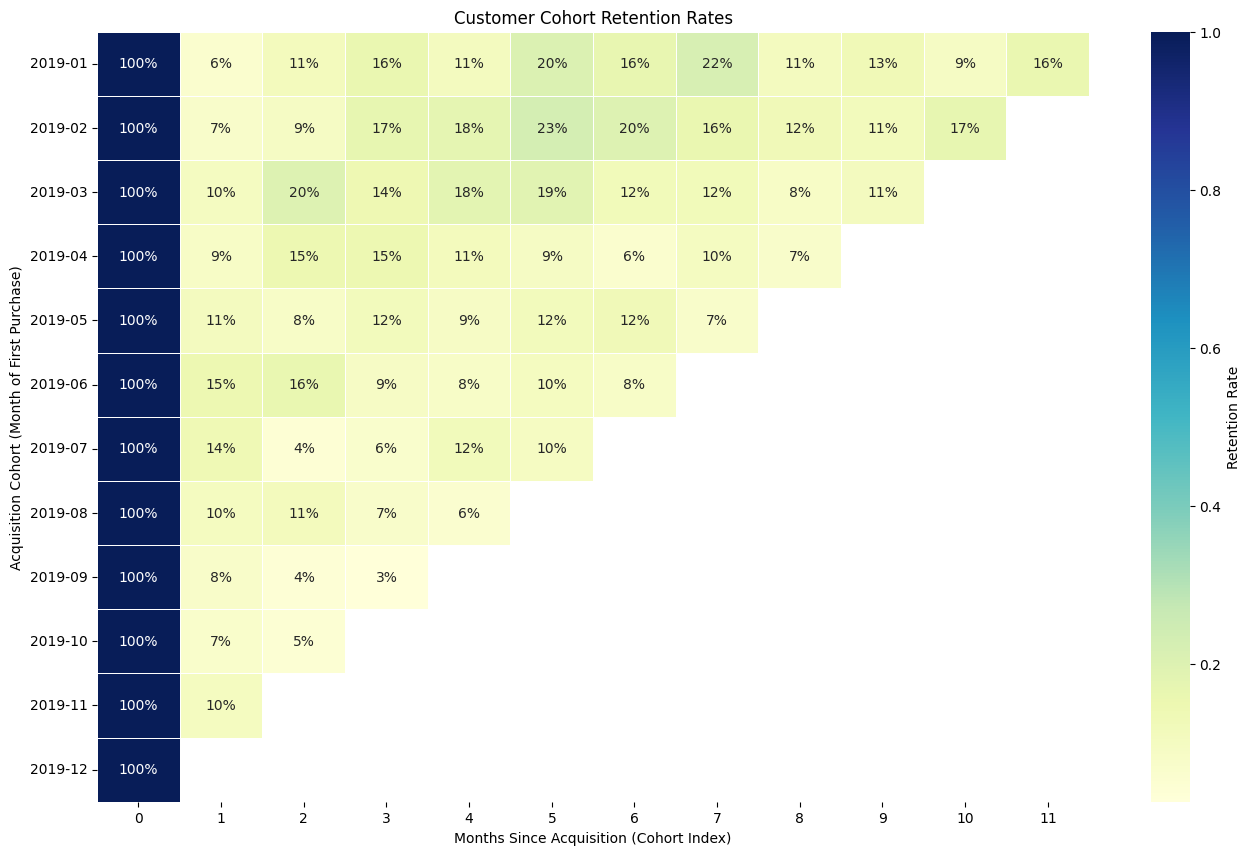


Highest retention cohort (after 1 month): 2019-06 (Retention: 14.60%)
Lowest retention cohort (after 1 month): 2019-01 (Retention: 6.05%)


In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 10))
sns.heatmap(
    retention_matrix,
    annot=True,
    fmt='.0%',
    cmap='YlGnBu',
    linewidths=.5,
    cbar_kws={'label': 'Retention Rate'}
)
plt.title('Customer Cohort Retention Rates')
plt.xlabel('Months Since Acquisition (Cohort Index)')
plt.ylabel('Acquisition Cohort (Month of First Purchase)')
plt.yticks(rotation=0) # Ensure month labels are horizontal
plt.show()

# Identify highest and lowest retention cohorts
# We'll look at retention after the first month (Cohort_Index = 1) for a good indicator
# Assuming Cohort_Index 1 is present in most cohorts
if 1 in retention_matrix.columns:
    retention_after_month1 = retention_matrix[1].dropna()
    highest_retention_cohort = retention_after_month1.idxmax()
    lowest_retention_cohort = retention_after_month1.idxmin()

    print(f"\nHighest retention cohort (after 1 month): {highest_retention_cohort} (Retention: {retention_after_month1.max():.2%})")
    print(f"Lowest retention cohort (after 1 month): {lowest_retention_cohort} (Retention: {retention_after_month1.min():.2%})")
else:
    print("Cannot determine highest/lowest retention cohorts at Cohort Index 1 due to insufficient data.")

### Strategies to Improve Retention for Weaker Cohorts

Based on the cohort retention analysis (especially identifying months with the lowest retention rates), here are general strategies to improve retention for weaker cohorts:

1.  **Enhanced Onboarding for New Customers (Early Cohort Indexes):**
    *   **Problem:** If early retention (Cohort Index 1 or 2) is low, it suggests new customers are not finding immediate value or are encountering friction.
    *   **Strategy:** Implement a robust onboarding program. This could include welcome emails, product tutorials, live chat support, a dedicated 'getting started' guide, or personalized recommendations based on their first purchase. Ensure they understand the full value proposition of your products/services.

2.  **Targeted Re-engagement Campaigns (Mid-Cohort Indexes):**
    *   **Problem:** If retention drops significantly after a few months, customers might be losing interest or forgetting about the brand.
    *   **Strategy:** Develop automated email or notification campaigns triggered by inactivity. These could offer personalized discounts on past viewed items, showcase new product arrivals, or remind them of loyalty program benefits. Highlight how your products can solve their ongoing needs.

3.  **Personalized Communication and Offers:**
    *   **Problem:** Generic communication can lead to disengagement.
    *   **Strategy:** Use customer data (purchase history, browsing behavior) to tailor messages and promotions. For example, if a cohort frequently purchased 'Apparel', send them updates on new clothing lines or related accessories. Make them feel understood and valued.

4.  **Feedback and Issue Resolution:**
    *   **Problem:** Customers may churn due to unmet expectations or unresolved issues.
    *   **Strategy:** Actively solicit feedback from all cohorts, especially those showing signs of declining engagement. Implement quick and effective customer support to resolve problems promptly. Consider sending post-purchase surveys to gauge satisfaction.

5.  **Build Community and Brand Loyalty:**
    *   **Problem:** Lack of emotional connection to the brand.
    *   **Strategy:** Create opportunities for customers to engage with your brand beyond transactions. This could involve social media contests, user-generated content features, loyalty programs with exclusive perks, or events (online/offline) that foster a sense of community.

6.  **Analyze Churn Drivers:**
    *   **Problem:** There might be specific reasons causing customers from certain cohorts to leave.
    *   **Strategy:** Conduct exit surveys or analyze common characteristics of churning customers within weaker cohorts (e.g., product category, location, initial discount used). This diagnostic step can reveal underlying issues that need to be addressed.

7.  **Optimize Product Offering and Experience:**
    *   **Problem:** The product itself might not be meeting expectations or evolving with customer needs.
    *   **Strategy:** Regularly review product performance and customer reviews. Use feedback to make continuous improvements or introduce new features/products that cater to evolving demands. A strong product is the foundation of good retention.

By systematically applying these strategies to the cohorts identified with lower retention rates, the company can work towards improving customer lifetime value and ensuring more consistent growth across all segments.

## Analyzing the lifetime value of customers acquired in different months. Insights on acquisition and retention strategies.

### Analyzing Lifetime Value (LTV) by Acquisition Cohort

In [44]:
# 1. Calculate Total Monetary Value (LTV) for each Customer
customer_ltv = merged_df.groupby('CustomerID')['Invoice_Value'].sum().reset_index()
customer_ltv.rename(columns={'Invoice_Value': 'Lifetime_Value'}, inplace=True)

# 2. Merge LTV with Customer Acquisition Dates
# We already have `customer_acquisition_dates` from previous steps
ltv_by_acquisition = pd.merge(
    customer_ltv,
    customer_acquisition_dates[['CustomerID', 'Acquisition_Month']],
    on='CustomerID',
    how='left'
)

# 3. Calculate Average LTV per Acquisition Month
average_ltv_per_cohort = ltv_by_acquisition.groupby('Acquisition_Month')['Lifetime_Value'].mean().reset_index()
average_ltv_per_cohort.rename(columns={'Lifetime_Value': 'Average_LTV'}, inplace=True)

# Sort by month for better presentation (optional)
month_order_period = pd.PeriodIndex(customer_acquisition_dates['Acquisition_Month'].unique(), freq='M')
average_ltv_per_cohort['Acquisition_Month'] = pd.Categorical(
    average_ltv_per_cohort['Acquisition_Month'],
    categories=month_order_period,
    ordered=True
)
average_ltv_per_cohort = average_ltv_per_cohort.sort_values('Acquisition_Month')

print("Average Lifetime Value by Acquisition Month:")
display(average_ltv_per_cohort)

Average Lifetime Value by Acquisition Month:


,Acquisition_Month,Average_LTV
8,2019-09,2155.228048
2,2019-03,4346.367360
5,2019-06,2428.332657
11,2019-12,2485.046487
7,2019-08,2238.371097
4,2019-05,3449.168665
6,2019-07,2955.430515
1,2019-02,6625.761391
9,2019-10,3114.370431
3,2019-04,3211.438752


### Visualizing Average LTV by Acquisition Month

/tmp/ipykernel_1253/2756908773.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Acquisition_Month', y='Average_LTV', data=average_ltv_per_cohort, palette='viridis')


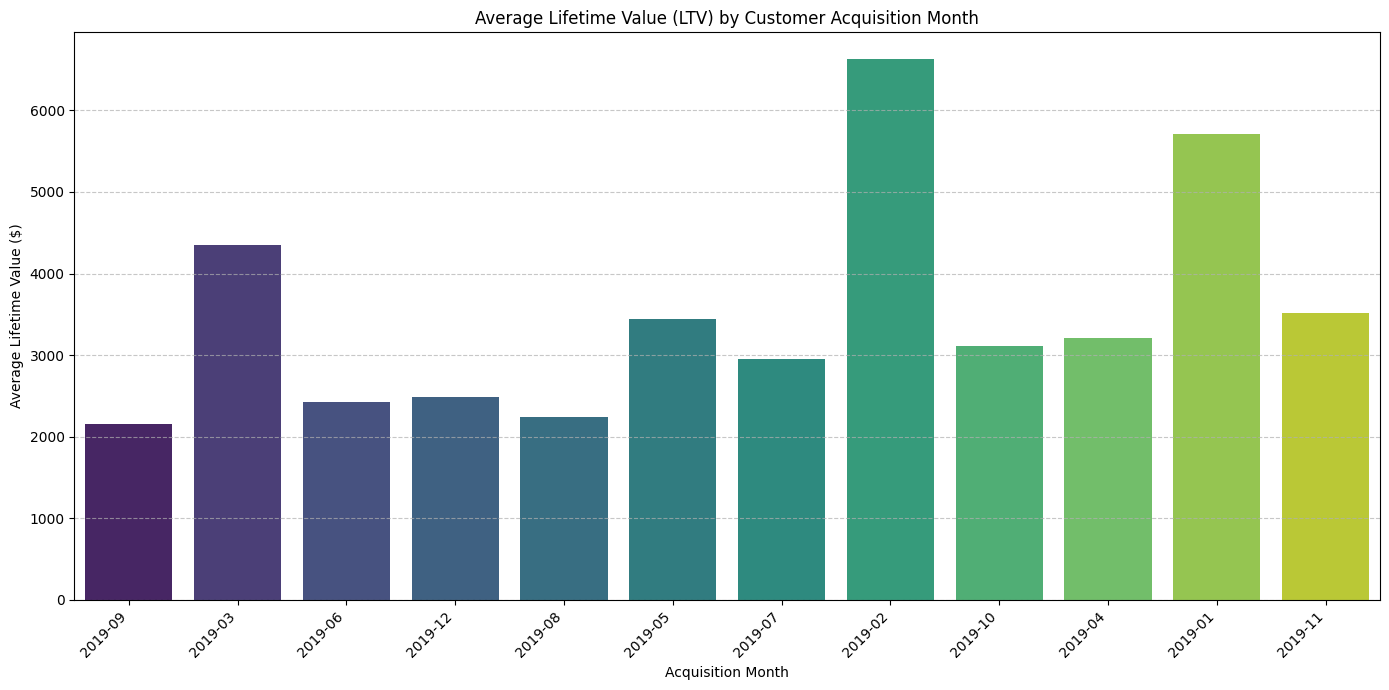


Month with highest Average LTV: 2019-02 (Average LTV: $6625.76)
Month with lowest Average LTV: 2019-09 (Average LTV: $2155.23)


In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.barplot(x='Acquisition_Month', y='Average_LTV', data=average_ltv_per_cohort, palette='viridis')
plt.title('Average Lifetime Value (LTV) by Customer Acquisition Month')
plt.xlabel('Acquisition Month')
plt.ylabel('Average Lifetime Value ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Identify highest and lowest LTV cohorts
highest_ltv_cohort = average_ltv_per_cohort.loc[average_ltv_per_cohort['Average_LTV'].idxmax()]
lowest_ltv_cohort = average_ltv_per_cohort.loc[average_ltv_per_cohort['Average_LTV'].idxmin()]

print(f"\nMonth with highest Average LTV: {highest_ltv_cohort['Acquisition_Month']} (Average LTV: ${highest_ltv_cohort['Average_LTV']:.2f})")
print(f"Month with lowest Average LTV: {lowest_ltv_cohort['Acquisition_Month']} (Average LTV: ${lowest_ltv_cohort['Average_LTV']:.2f})")

### Informing Acquisition and Retention Strategies with LTV Insights

Analyzing the Lifetime Value (LTV) of customers based on their acquisition month provides crucial insights that can significantly inform and optimize both acquisition and retention strategies:

**A. Informing Acquisition Strategies:**

1.  **Optimize Marketing Spend:**
    *   **Insight:** If certain acquisition months consistently yield higher LTV cohorts, it indicates that the marketing channels, campaigns, or product offerings during those periods were particularly effective at attracting high-value customers.
    *   **Strategy:** Allocate more marketing budget and resources towards campaigns and channels that were active during high-LTV acquisition months. Conversely, re-evaluate or reduce spend on periods/channels associated with low-LTV cohorts.

2.  **Targeting Refinement:**
    *   **Insight:** High-LTV cohorts might share common characteristics (e.g., demographics, referral source, initial product purchased).
    *   **Strategy:** Refine audience targeting for acquisition campaigns to focus on segments that resemble customers from high-LTV cohorts. This ensures you're not just acquiring customers, but acquiring *valuable* customers.

3.  **Offer Optimization:**
    *   **Insight:** The types of promotions or products offered during high-LTV acquisition months may attract customers who are more likely to spend more over time.
    *   **Strategy:** Experiment with replicating successful introductory offers or product bundles that coincided with high-LTV cohort acquisitions.

**B. Informing Retention Strategies:**

1.  **Proactive Engagement for Low-LTV Cohorts:**
    *   **Insight:** If a cohort has a consistently low average LTV, it suggests these customers might be churning quickly or making fewer repeat purchases.
    *   **Strategy:** Implement early and proactive retention campaigns for customers newly acquired in months typically associated with low LTV. This could include enhanced onboarding, personalized follow-ups, or special incentives to encourage a second purchase.

2.  **Reinforce Value for High-LTV Cohorts:**
    *   **Insight:** High-LTV cohorts are your most valuable. Understanding *why* they stay and spend more is key.
    *   **Strategy:** Deeply analyze the behavior and preferences of high-LTV cohorts. What products do they buy? How often? What kind of communication do they respond to? Use these insights to create tailored loyalty programs, exclusive content, or VIP experiences that reinforce their value and encourage continued engagement.

3.  **Identify Churn Risks Early:**
    *   **Insight:** A sudden drop in LTV for a specific acquisition cohort could signal a change in market conditions, product perception, or a failed retention initiative.
    *   **Strategy:** Monitor LTV trends by cohort over time. If a cohort's LTV isn't growing as expected, intervene with targeted re-engagement campaigns or customer support initiatives.

4.  **Personalized Retention Efforts:**
    *   **Insight:** Different cohorts might respond to different retention tactics.
    *   **Strategy:** Segment customers not just by their current RFM score, but also by their acquisition cohort. Tailor retention messages and offers based on the specific LTV potential and historical behavior of their cohort.

By systematically tracking and analyzing LTV by acquisition cohort, the e-commerce company can move beyond simply acquiring customers to strategically acquiring and nurturing customers who will deliver the highest long-term value to the business.

## Identifying seasonal trends in sales by category and location. Company preparation for peak and off-peak seasons to maximize revenue.

### Analyzing Seasonal Sales Trends by Category and Location

In [46]:
# Ensure 'Transaction_Date' is datetime type (already done, but good to re-check)
merged_df['Transaction_Date'] = pd.to_datetime(merged_df['Transaction_Date'])

# Extract Year and Month from Transaction_Date
merged_df['Year'] = merged_df['Transaction_Date'].dt.year
merged_df['Month_Name'] = merged_df['Transaction_Date'].dt.month_name()

# Merge customer location data into merged_df
# Assuming customer_df has 'CustomerID' and 'Location'
seasonal_sales_df = pd.merge(
    merged_df,
    customer_df[['CustomerID', 'Location']],
    on='CustomerID',
    how='left'
)

# Group by Year, Month, Product_Category, and Location to sum Invoice_Value
seasonal_trends = seasonal_sales_df.groupby(['Year', 'Month_Name', 'Product_Category', 'Location'])['Invoice_Value'].sum().reset_index()

# Order months for chronological plotting
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
seasonal_trends['Month_Name'] = pd.Categorical(seasonal_trends['Month_Name'], categories=month_order, ordered=True)
seasonal_trends = seasonal_trends.sort_values(by=['Year', 'Month_Name'])

print("Seasonal Sales Trends (Top 5 rows):")
display(seasonal_trends.head())

Seasonal Sales Trends (Top 5 rows):


,Year,Month_Name,Product_Category,Location,Invoice_Value
297,2019,January,Accessories,Chicago,63.22700
298,2019,January,Android,California,51.56380
299,2019,January,Android,Chicago,24.65000
300,2019,January,Android,New York,26.91380
301,2019,January,Apparel,California,22272.33154


### Visualizing Overall Monthly Sales Trends

/tmp/ipykernel_1253/1521955737.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  overall_monthly_sales = seasonal_trends.groupby('Month_Name')['Invoice_Value'].sum().reset_index()


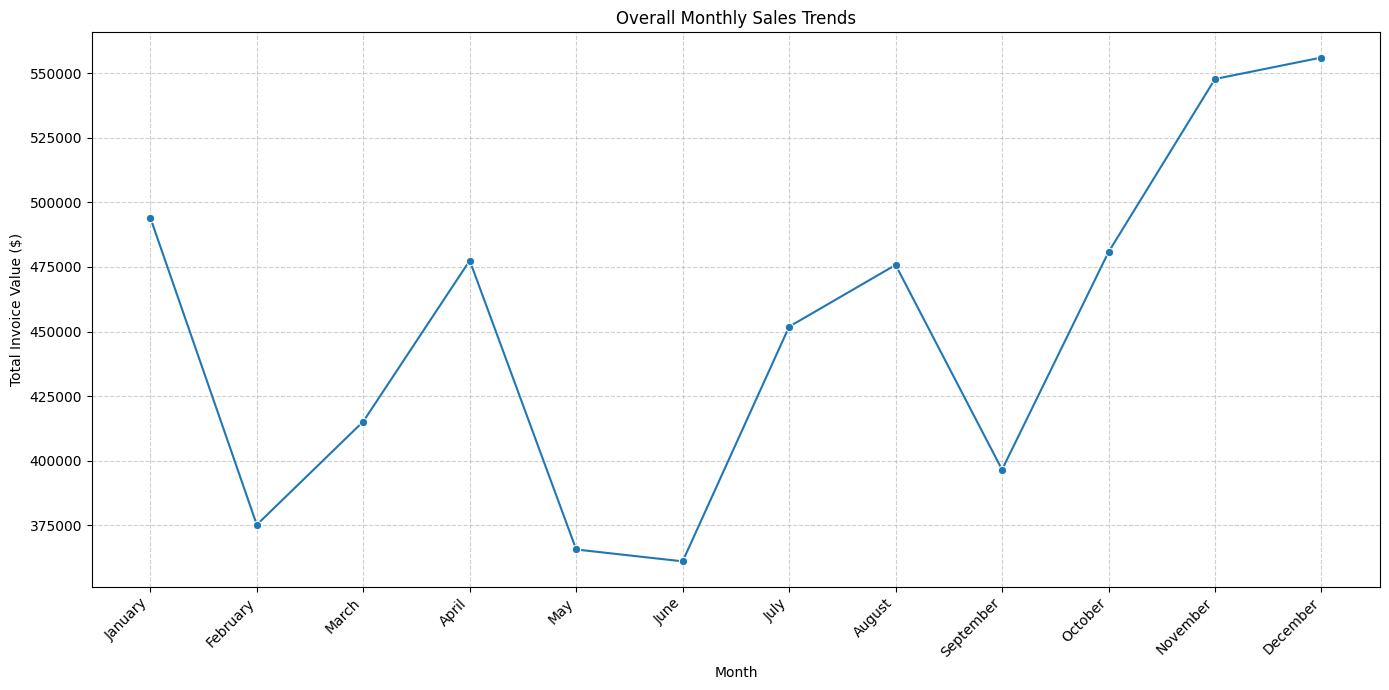

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate overall monthly sales
overall_monthly_sales = seasonal_trends.groupby('Month_Name')['Invoice_Value'].sum().reset_index()
overall_monthly_sales['Month_Name'] = pd.Categorical(overall_monthly_sales['Month_Name'], categories=month_order, ordered=True)
overall_monthly_sales = overall_monthly_sales.sort_values('Month_Name')

plt.figure(figsize=(14, 7))
sns.lineplot(x='Month_Name', y='Invoice_Value', data=overall_monthly_sales, marker='o')
plt.title('Overall Monthly Sales Trends')
plt.xlabel('Month')
plt.ylabel('Total Invoice Value ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Visualizing Sales Trends by Top Product Categories

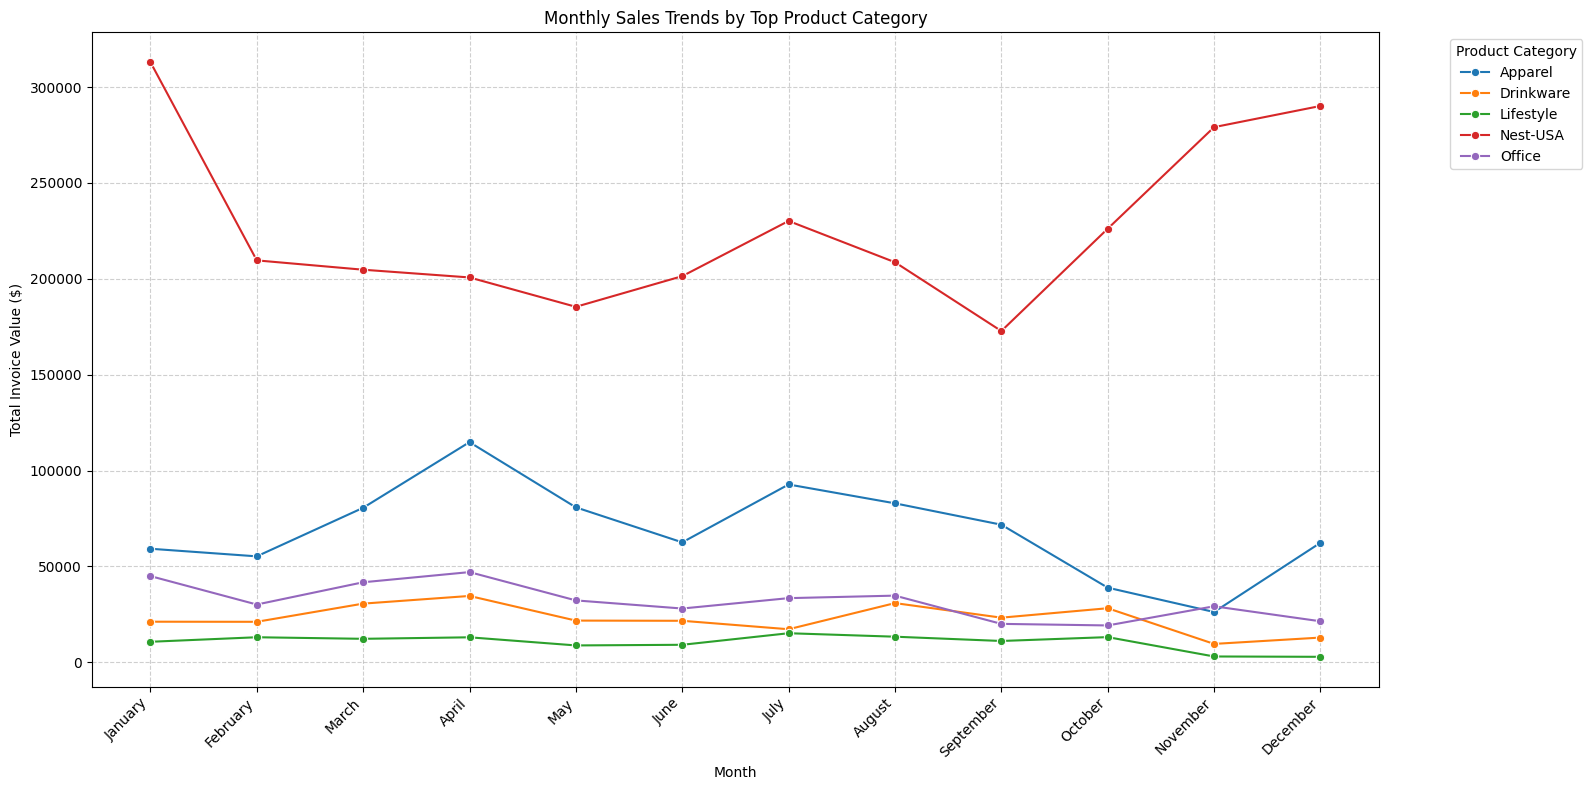

In [48]:
# Identify top N product categories for visualization
top_categories = seasonal_sales_df['Product_Category'].value_counts().head(5).index.tolist()

sales_by_category_month = seasonal_sales_df[seasonal_sales_df['Product_Category'].isin(top_categories)]
sales_by_category_month = sales_by_category_month.groupby(['Month_Name', 'Product_Category'])['Invoice_Value'].sum().reset_index()
sales_by_category_month['Month_Name'] = pd.Categorical(sales_by_category_month['Month_Name'], categories=month_order, ordered=True)
sales_by_category_month = sales_by_category_month.sort_values(by=['Month_Name', 'Product_Category'])

plt.figure(figsize=(16, 8))
sns.lineplot(x='Month_Name', y='Invoice_Value', hue='Product_Category', data=sales_by_category_month, marker='o')
plt.title('Monthly Sales Trends by Top Product Category')
plt.xlabel('Month')
plt.ylabel('Total Invoice Value ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Visualizing Sales Trends by Top Locations

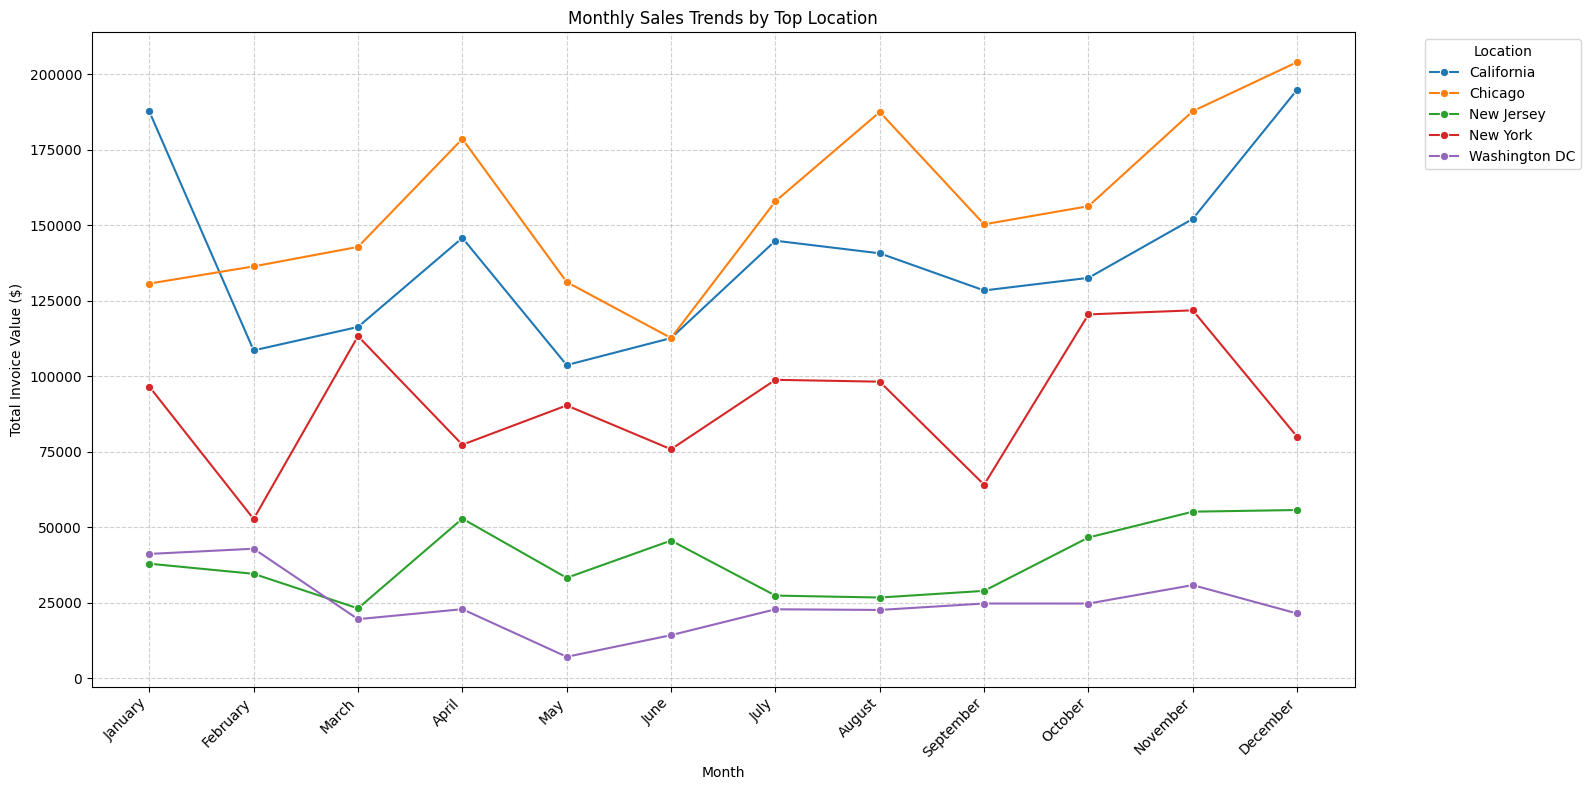

In [49]:
# Identify top N locations for visualization
top_locations = seasonal_sales_df['Location'].value_counts().head(5).index.tolist()

sales_by_location_month = seasonal_sales_df[seasonal_sales_df['Location'].isin(top_locations)]
sales_by_location_month = sales_by_location_month.groupby(['Month_Name', 'Location'])['Invoice_Value'].sum().reset_index()
sales_by_location_month['Month_Name'] = pd.Categorical(sales_by_location_month['Month_Name'], categories=month_order, ordered=True)
sales_by_location_month = sales_by_location_month.sort_values(by=['Month_Name', 'Location'])

plt.figure(figsize=(16, 8))
sns.lineplot(x='Month_Name', y='Invoice_Value', hue='Location', data=sales_by_location_month, marker='o')
plt.title('Monthly Sales Trends by Top Location')
plt.xlabel('Month')
plt.ylabel('Total Invoice Value ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Location', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Strategies for Maximizing Revenue During Peak and Off-Peak Seasons

Based on the analysis of seasonal trends in sales by category and location, here are strategies to prepare for peak and off-peak seasons:

**A. During Peak Seasons (e.g., months with highest overall sales, high category-specific sales):**

1.  **Inventory Management:**
    *   **Proactive Stocking:** Forecast demand accurately for top-performing categories and locations. Pre-order and increase stock levels well in advance to avoid stockouts.
    *   **Buffer Stock:** Maintain additional safety stock for high-demand items to handle unexpected spikes.
    *   **Supplier Relationships:** Strengthen relationships with suppliers to ensure timely deliveries and potentially negotiate better terms for bulk orders.

2.  **Marketing & Promotions:**
    *   **Strategic Campaigns:** Launch targeted marketing campaigns focusing on best-selling products and categories. Use themes relevant to the peak season (e.g., holiday sales, back-to-school).
    *   **Limited-Time Offers:** Use urgency and scarcity tactics with flash sales or limited-time discounts on popular items to boost conversion.
    *   **Cross-selling/Upselling:** Promote complementary products or higher-value versions of popular items.
    *   **Personalization:** Leverage customer data to send highly personalized offers during peak times.

3.  **Operations & Logistics:**
    *   **Staffing:** Increase customer service and fulfillment staff to handle higher order volumes and inquiries efficiently.
    *   **Delivery Optimization:** Partner with reliable shipping carriers and offer expedited shipping options. Communicate potential delays clearly to customers.
    *   **Website Performance:** Ensure the e-commerce website is robust and can handle increased traffic without performance issues.

**B. During Off-Peak Seasons (e.g., months with lowest overall sales, low category-specific sales):**

1.  **Inventory Management:**
    *   **Clearance & Bundling:** Implement clearance sales for excess inventory from the previous peak season or slow-moving items.
    *   **Bundling:** Create attractive bundles of products (e.g., popular + less popular) to increase perceived value and move inventory.
    *   **Supplier Negotiations:** Use off-peak periods to negotiate better terms with suppliers for future orders.

2.  **Marketing & Promotions:**
    *   **Brand Building & Awareness:** Shift focus from direct sales to brand building and awareness campaigns. Invest in content marketing, social media engagement, and community building.
    *   **Targeted Re-engagement:** Launch re-engagement campaigns for inactive customers or those who purchased during the last peak season.
    *   **Niche Promotions:** Focus on niche categories or products that might have year-round appeal or cater to specific off-season needs.
    *   **Subscription Models/Loyalty Programs:** Promote subscription services or highlight loyalty program benefits to encourage consistent purchases.
    *   **Educational Content:** Provide content that educates customers about product benefits or new ways to use existing products.

3.  **Operations & Logistics:**
    *   **Maintenance & Upgrades:** Use quieter periods to perform website maintenance, system upgrades, or staff training.
    *   **Process Improvement:** Review and optimize internal processes for efficiency and cost reduction.
    *   **Customer Feedback:** Actively collect and analyze customer feedback to identify areas for improvement in products or services.

**C. Location-Specific Strategies:**

*   **Local Marketing:** For locations showing specific seasonal trends, run geo-targeted marketing campaigns. For example, if 'New York' sees a dip in summer, run specific campaigns for summer essentials there.
*   **Product Assortment:** Tailor product assortments to local preferences or seasonal needs of specific locations.
*   **Partnerships:** Form local partnerships or collaborations to boost visibility in certain regions during their respective off-peak times.

By implementing these tailored strategies, the company can effectively navigate seasonal fluctuations, maximize revenue during peak times, and strategically drive engagement and sales during off-peak periods.

In [ ]:
## Analyze daily sales trends to identify high-performing and low-performing days. What strategies can be implemented to boost sales on slower days?

In [50]:
merged_df['Day_of_Week'] = merged_df['Transaction_Date'].dt.day_name()

daily_sales_trends = merged_df.groupby('Day_of_Week')['Invoice_Value'].sum().reset_index()

# Define the order of days for consistent plotting
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_sales_trends['Day_of_Week'] = pd.Categorical(daily_sales_trends['Day_of_Week'], categories=day_order, ordered=True)
daily_sales_trends = daily_sales_trends.sort_values('Day_of_Week')

print("Daily Sales Trends:")
display(daily_sales_trends)

# Identify high-performing and low-performing days
highest_sales_day = daily_sales_trends.loc[daily_sales_trends['Invoice_Value'].idxmax()]
lowest_sales_day = daily_sales_trends.loc[daily_sales_trends['Invoice_Value'].idxmin()]

print(f"\nHighest performing day: {highest_sales_day['Day_of_Week']} (Total Sales: ${highest_sales_day['Invoice_Value']:.2f})")
print(f"Lowest performing day: {lowest_sales_day['Day_of_Week']} (Total Sales: ${lowest_sales_day['Invoice_Value']:.2f})")

Daily Sales Trends:


,Day_of_Week,Invoice_Value
1,Monday,412681.88924
5,Tuesday,450233.69110
6,Wednesday,956308.44438
4,Thursday,974511.96144
0,Friday,998722.68836
2,Saturday,791133.55953
3,Sunday,813766.51229



Highest performing day: Friday (Total Sales: $998722.69)
Lowest performing day: Monday (Total Sales: $412681.89)


### Visualizing Daily Sales Trends

/tmp/ipykernel_1253/2507619147.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Day_of_Week', y='Invoice_Value', data=daily_sales_trends, palette='viridis')


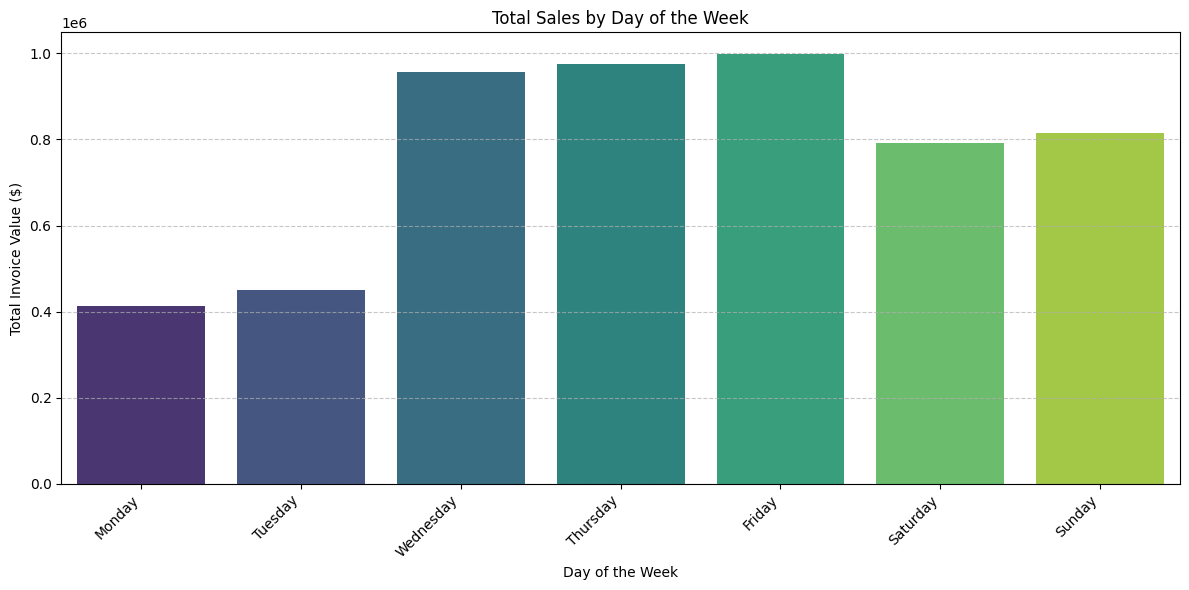

In [51]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Day_of_Week', y='Invoice_Value', data=daily_sales_trends, palette='viridis')
plt.title('Total Sales by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Total Invoice Value ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Strategies to Boost Sales on Slower Days

Based on the identified high-performing and low-performing days, here are strategies to boost sales on slower days:

**1. Understand the 'Why' behind Slower Days:**
*   **Analyze Traffic Patterns:** Are there fewer website visitors on these days? Or is conversion lower? Tools like Google Analytics can provide insights.
*   **Competitor Activity:** Are competitors running strong promotions on these days, or are they also experiencing a slowdown?
*   **Customer Behavior:** Do customers typically engage in other activities on these days (e.g., weekend errands, work commitments) that divert their attention from online shopping?

**2. Targeted Promotions and Offers:**
*   **"Slow Day" Specials:** Introduce specific discounts, flash sales, or bundles available only on the lowest performing days. For example, "Tuesday Treats" or "Mid-Week Markdown."
*   **Free Shipping Thresholds:** Offer slightly lower free shipping thresholds on slower days to encourage smaller purchases.
*   **Loyalty Point Boosts:** Provide extra loyalty points for purchases made on slow days.
*   **Exclusive Content/Early Access:** Offer exclusive content, sneak peeks of new products, or early access to upcoming sales for purchases made on these days.

**3. Marketing and Communication Strategies:**
*   **Email Marketing:** Send targeted email campaigns to subscribers reminding them of the special offers available on the slower days.
*   **Social Media Campaigns:** Run social media posts and ads specifically promoting the slow-day deals. Use engaging content to capture attention.
*   **Content Marketing:** Publish blog posts or articles on slower days that drive traffic and subtly promote products (e.g., "Top 5 Products for a Relaxing Wednesday Evening").
*   **Retargeting Ads:** Use retargeting campaigns to remind customers who visited your site but didn't purchase to come back on the slower days for special deals.

**4. Operational Adjustments:**
*   **Customer Service Availability:** Ensure adequate customer service staff are available on slower days to assist customers and improve conversion.
*   **Product Launches/Announcements:** Consider timing smaller product launches or major announcements for slower days to generate excitement and drive traffic when it's otherwise quiet.

**5. Experiment with Value-Added Services:**
*   **Personal Shopping Sessions:** Offer free virtual personal shopping consultations on slower days.
*   **Educational Workshops/Webinars:** Host free online workshops or webinars related to your products on quieter days, positioning your brand as a resource.

By implementing a combination of these strategies, businesses can strategically increase engagement and sales on days that traditionally see lower activity, ultimately leading to more consistent revenue throughout the week.